1. INSTALL DEPENDENCIES

In [ ]:
!pip install langchain chromadb sentence-transformers langchain-community

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.0/23.0 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 

2. IMPORT LIBRARIES

In [ ]:
!pip install -U langchain langchain-community chromadb sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.7/112.7 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.8/169.8 kB 14.6 MB/s eta 0:00:00
  Attempting uninstall: langgraph-prebuilt
    Found existing installation: langgraph-prebuilt 1.0.8
    Uninstalling langgraph-prebuilt-1.0.8:
      Successfully uninstalled langgraph-prebuilt-1.0.8
  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.1.4
    Uninstalling langgraph-1.1.4:
      Successfully uninstalled langgraph-1.1.4
  Attempting uninstall: langchain
    Found existing installation: langchain 1.2.14
    Uninstalling langchain-1.2.14:
      Successfully uninstalled langchain-1.2.14


In [ ]:
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_core.documents import Document
import matplotlib.pyplot as plt

3. CREATE DOCUMENTS

In [ ]:
doc1 = Document(
    page_content="Virat Kohli is one of the most successful batsmen in IPL history.",
    metadata={"team": "RCB"}
)

doc2 = Document(
    page_content="Rohit Sharma is the most successful IPL captain with multiple titles.",
    metadata={"team": "MI"}
)

doc3 = Document(
    page_content="MS Dhoni is known for leadership and finishing skills in IPL.",
    metadata={"team": "CSK"}
)

doc4 = Document(
    page_content="Jasprit Bumrah is one of the best fast bowlers in T20 cricket.",
    metadata={"team": "MI"}
)

doc5 = Document(
    page_content="Ravindra Jadeja is a top all-rounder with excellent fielding.",
    metadata={"team": "CSK"}
)

docs = [doc1, doc2, doc3, doc4, doc5]

4. LOAD EMBEDDING MODEL

In [ ]:
embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

/tmp/ipykernel_3077/2127729888.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

5. CREATE VECTOR DATABASE

In [ ]:
vector_store = Chroma(
    embedding_function=embedding_model,
    persist_directory='chroma_db',
    collection_name='ipl_data'
)

/tmp/ipykernel_3077/866089264.py:4: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vector_store = Chroma(


6. ADD DOCUMENTS TO DATABASE

In [ ]:
vector_store.add_documents(docs)

['616ac962-3b8b-4b50-a041-629bfff632a8',
 'baa8300f-970a-4064-a5ca-70d0aaf12840',
 '17a8d6f3-c2ab-4bed-bf8f-fec23136d3c1',
 '759f4ed0-d7de-467a-94e9-82db1c43cacc',
 'e3249586-e2ac-407e-bf6e-38899b1eb17e']

7. SEMANTIC SEARCH

In [ ]:
query = "Who is a bowler?"

results = vector_store.similarity_search_with_score(
    query=query,
    k=3
)

8. DISPLAY RESULTS

In [ ]:
print("Query:", query)
print("\nTop Results:\n")

scores = []

for doc, score in results:
    print("Text:", doc.page_content)
    print("Team:", doc.metadata)
    print("Similarity Score:", score)
    print("-" * 50)
    scores.append(score)

Query: Who is a bowler?

Top Results:

Text: Jasprit Bumrah is one of the best fast bowlers in T20 cricket.
Team: {'team': 'MI'}
Similarity Score: 0.99701327085495
--------------------------------------------------
Text: Virat Kohli is one of the most successful batsmen in IPL history.
Team: {'team': 'RCB'}
Similarity Score: 1.1878081560134888
--------------------------------------------------
Text: Ravindra Jadeja is a top all-rounder with excellent fielding.
Team: {'team': 'CSK'}
Similarity Score: 1.2411137819290161
--------------------------------------------------


9. METADATA FILTERING

In [ ]:
print("\nFiltered Results (CSK Players):\n")

filtered_results = vector_store.similarity_search_with_score(
    query="",
    filter={"team": "CSK"}
)

for doc, score in filtered_results:
    print(doc.page_content, "| Score:", score)


Filtered Results (CSK Players):

MS Dhoni is known for leadership and finishing skills in IPL. | Score: 1.844998836517334
MS Dhoni is known for leadership and finishing skills in IPL. | Score: 1.844998836517334
Ravindra Jadeja is a top all-rounder with excellent fielding. | Score: 1.8608676195144653
Ravindra Jadeja is a top all-rounder with excellent fielding. | Score: 1.8608676195144653


10. GRAPH (SIMILARITY SCORES)

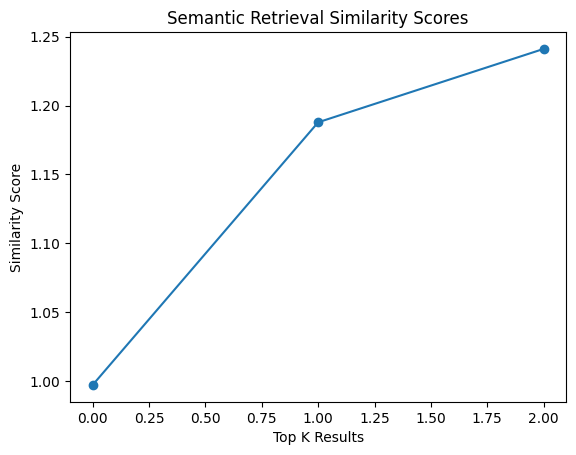

In [ ]:
plt.plot(scores, marker='o')
plt.title("Semantic Retrieval Similarity Scores")
plt.xlabel("Top K Results")
plt.ylabel("Similarity Score")
plt.show()